In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

INPUT_LENGTH = 36
OUTPUT_LENGTH = 3

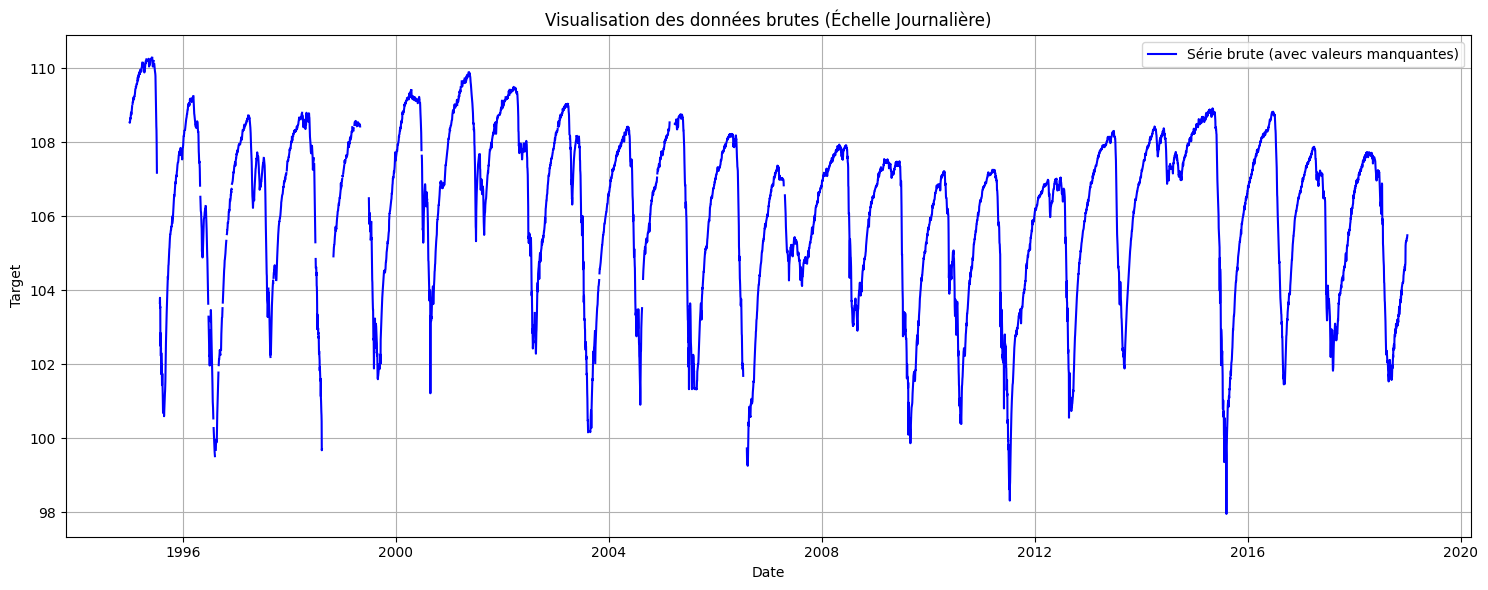

In [22]:
#1)
df_train_init = pd.read_csv(
	"train.csv", 
	sep=';', 
	parse_dates=['date'], 
	index_col='date'
)

df_test_init = pd.read_csv(
	"test.csv", 
	sep=';', 
	parse_dates=['date'], 
	index_col='date'
)

plt.figure(figsize=(15, 6))
plt.plot(df_train_init.index, df_train_init['target'], label='Série brute (avec valeurs manquantes)', color='blue')

plt.title('Visualisation des données brutes (Échelle Journalière)')
plt.xlabel('Date')
plt.ylabel('Target')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

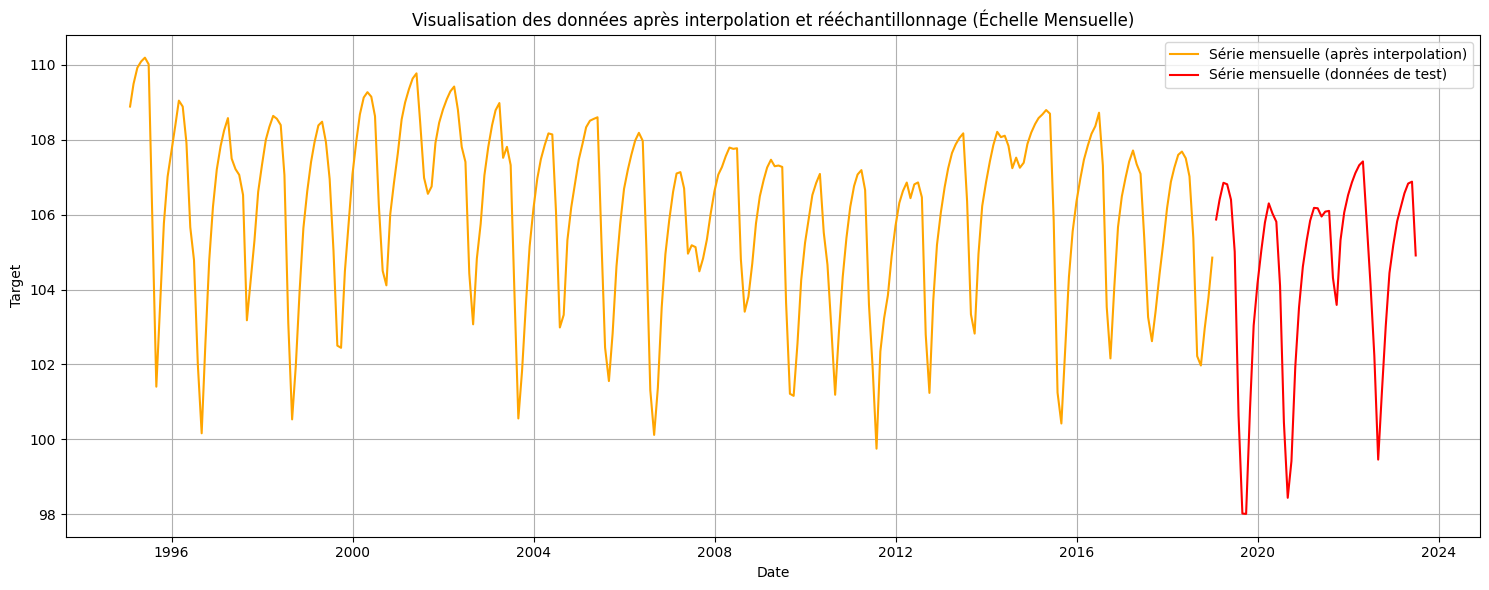

In [23]:
#2)
df_train_interpolated = df_train_init.interpolate(method='time')
df_train_monthly = df_train_interpolated.resample('ME').mean()

df_test_interpolated = df_test_init.interpolate(method='time')
df_test_monthly = df_test_interpolated.resample('ME').mean()

plt.figure(figsize=(15, 6))
plt.plot(df_train_monthly.index, df_train_monthly['target'], label='Série mensuelle (après interpolation)', color='orange')
plt.plot(df_test_monthly.index, df_test_monthly['target'], label='Série mensuelle (données de test)', color='red')
plt.title('Visualisation des données après interpolation et rééchantillonnage (Échelle Mensuelle)')
plt.xlabel('Date')
plt.ylabel('Target')
plt.grid(True)
plt.legend()
plt.tight_layout()

In [24]:
from sklearn.preprocessing import MinMaxScaler

def create_sequences(data, seq_length, target_col, output_lenght=1):
	xs = []
	ys = []
	for i in range(len(data) - seq_length - output_lenght + 1):
		x = data[target_col].iloc[:(i + seq_length)].values
		y = data[target_col].iloc[(i + seq_length):(i + seq_length + output_lenght)].values
		xs.append(x)
		ys.append(y)
		
	return torch.tensor(np.array(xs), dtype=torch.float32), torch.tensor(np.array(ys), dtype=torch.float32)


nb_valid = 48 

df_train = df_train_monthly[:-nb_valid].copy()
df_valid = df_train_monthly[-nb_valid:].copy()
df_test = df_test_monthly.copy()

# ---- NORMALISATION ----
scaler = MinMaxScaler()

df_train['target'] = scaler.fit_transform(df_train[['target']])
df_valid['target'] = scaler.transform(df_valid[['target']])
df_test['target'] = scaler.transform(df_test[['target']])
# -----------------------


In [25]:
class Model(nn.Module): 
	def __init__(self, output_dim, dense1_size, dense2_size):
		super(Model, self).__init__()

		self.lstm1 = nn.LSTM(input_size=1, hidden_size=12, batch_first=True)
		self.lstm2 = nn.LSTM(input_size=12, hidden_size=dense1_size, batch_first=True)
		self.dense1 = nn.Linear(dense1_size, dense2_size)
		self.dense2 = nn.Linear(dense2_size, output_dim)

	def forward(self, x):
		x = x.unsqueeze(-1)
		
		lstm1_out, _ = self.lstm1(x)
		lstm2_out, _ = self.lstm2(lstm1_out)
		
		out = self.dense1(lstm2_out[:, -1, :])
		out = torch.relu(out)
		out = self.dense2(out)
		
		return out

In [50]:
# L'erreur de l'algèbre linéaire (LinAlgError) arrive souvent parce que les paramètres (2,1,2)(2,1,2,12) 
# rendent le modèle trop complexe et instable à entraîner sur ces données spécifiques.
# On redescend d'un cran la complexité, ou on modifie la méthode d'initialisation des paramètres:
model = SARIMAX(
	endog=df_train['target'], 
	order=(3, 1, 3), 
	seasonal_order=(2, 2, 2, 12),
	enforce_stationarity=False,
	enforce_invertibility=False
)

# On retire également df_train['target'] de la fonction fit, 
# car on l'a déjà passé dans endog= lors de l'initialisation.
result = model.fit(disp=False)
		
print('End!')

c:\Users\kylia\OneDrive\Bureau\Cours\Apprentissage_IA\final lab\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


End!


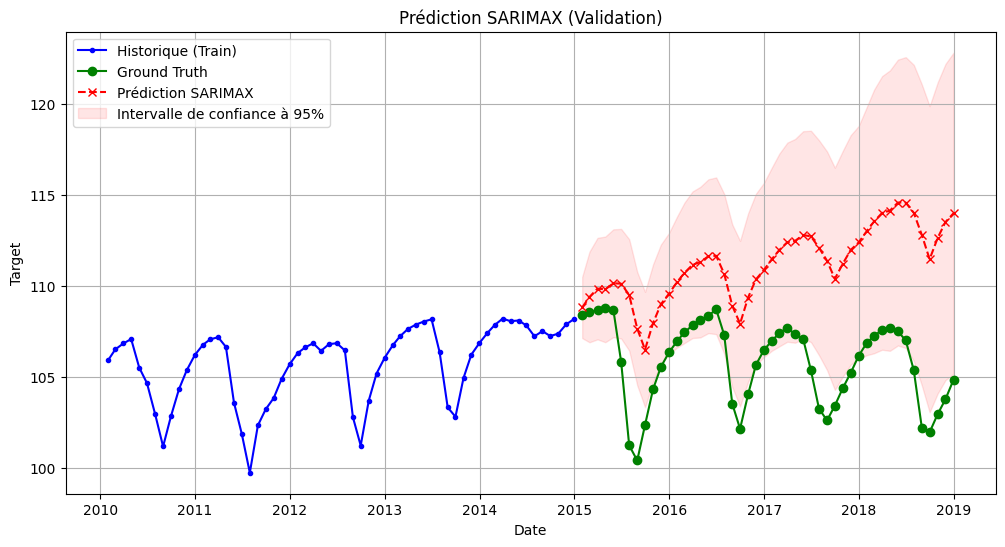

In [51]:
def plot_sarimax_prediction(result, df_train, df_test_or_valid, scaler=None, title="Prédiction SARIMAX"):
    # Obtenir les prédictions
    start_idx = len(df_train)
    end_idx = start_idx + len(df_test_or_valid) - 1
    
    # Prédiction
    forecast = result.get_prediction(start=start_idx, end=end_idx)
    pred_mean = forecast.predicted_mean
    pred_ci = forecast.conf_int()
    
    # Valeurs réelles vs prédictions
    true_target = df_test_or_valid['target'].values
    pred_target = pred_mean.values
    
    # Inversion de l'échelle si un scaler est fourni
    if scaler is not None:
        true_target = scaler.inverse_transform(true_target.reshape(-1, 1)).flatten()
        pred_target = scaler.inverse_transform(pred_target.reshape(-1, 1)).flatten()
        
        # Inversion des intervalles de confiance
        lower_bound = scaler.inverse_transform(pred_ci.iloc[:, 0].values.reshape(-1, 1)).flatten()
        upper_bound = scaler.inverse_transform(pred_ci.iloc[:, 1].values.reshape(-1, 1)).flatten()
    else:
        lower_bound = pred_ci.iloc[:, 0].values
        upper_bound = pred_ci.iloc[:, 1].values
        
    time_target = df_test_or_valid.index
    
    # Tracer le graphique
    plt.figure(figsize=(12, 6))
    
    # Historique de la fin de l'entraînement (pour le contexte visuel)
    hist_len = min(60, len(df_train))
    hist_idx = df_train.index[-hist_len:]
    hist_target = df_train['target'].values[-hist_len:]
    if scaler is not None:
        hist_target = scaler.inverse_transform(hist_target.reshape(-1, 1)).flatten()
        
    plt.plot(hist_idx, hist_target, label='Historique (Train)', color='blue', marker='.')
    plt.plot(time_target, true_target, label='Ground Truth', color='green', marker='o')
    plt.plot(time_target, pred_target, label='Prédiction SARIMAX', color='red', linestyle='--', marker='x')
    
    # Intervalle de confiance
    plt.fill_between(time_target, lower_bound, upper_bound, color='red', alpha=0.1, label='Intervalle de confiance à 95%')
    
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Target')
    plt.legend()
    plt.grid(True)
    plt.show()

# Afficher les prédictions sur les données de validation (qui ont servi de test ici)
plot_sarimax_prediction(result, df_train, df_valid, scaler=scaler, title="Prédiction SARIMAX (Validation)")